# Correct gradient nonlinearity over a large field of view

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/mrdistortion/blob/main/examples/01-gradient_nonlinearity.ipynb)

A gradient's field departs from linearity away from isocentre, so a straight
edge is imaged as a curved one and distances near the bore wall are wrong. The
departure is a property of the coil, so it is corrected by evaluating the coil's
own spherical harmonics over the image grid and resampling.

The coefficients here are a generic third-order coil, written out in code: no
vendor table is read, shipped or needed to see what the correction does.

In [1]:
try:
    import mrdistortion  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "mrdistortion", "matplotlib"],
        check=True,
    )

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import mrdistortion as mrd

ORDER = 3
FOV_MM = 400.0
SHAPE = (128, 128, 128)


def generic_coil(third_order: float = -0.06) -> mrd.GradientCoefficients:
    """A generic coil, given by how far it departs from being linear.

    The coefficients describe the departure, not the whole field: an all-zero
    table is a perfectly linear gradient and corrects to the identity. Each
    axis is stated in its own rotated frame, which is why every axis carries
    the same ``(n, m)``.
    """
    alpha = np.zeros((3, ORDER + 1, ORDER + 1))
    beta = np.zeros_like(alpha)
    for axis in range(3):
        alpha[axis, 3, 0] = third_order
    return mrd.GradientCoefficients(
        basis="normalized", alpha=alpha, beta=beta, reference_radius_mm=250.0
    )


def grid_phantom(shape: tuple[int, int, int], spacing: int = 12) -> np.ndarray:
    """A lattice, so the geometry of the correction is visible."""
    volume = np.zeros(shape)
    for axis in range(3):
        index = np.arange(shape[axis])
        on = (index % spacing) < 2
        volume += np.moveaxis(np.broadcast_to(on.reshape(-1, 1, 1), shape), 0, axis)
    return np.clip(volume, 0, 1)

In [3]:
geometry = mrd.ImageGeometry(
    shape=SHAPE,
    fov_mm=(FOV_MM,) * 3,
    direction=np.eye(3),
    center_mm=(0.0, 0.0, 0.0),
)
correct = mrd.Gradunwarp(generic_coil(), geometry)

phantom = grid_phantom(SHAPE)
corrected = correct(phantom)

displacement: median 3.35 mm, max 25.99 mm over a 400 mm FOV
a perfectly linear coil is an all-zero table and corrects to identity


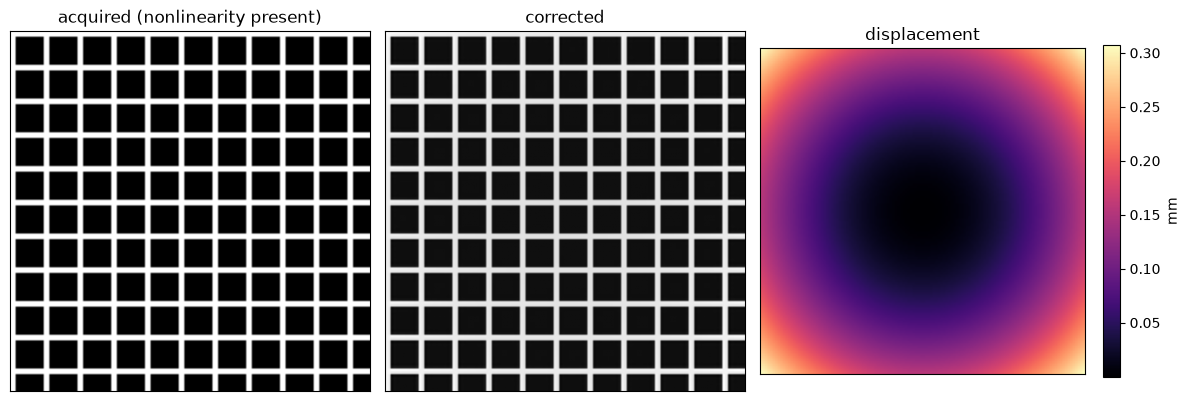

In [4]:
# Where each voxel really was, in millimetres of displacement.
grid = correct.sampling_grid()
centre = np.stack(np.meshgrid(*[np.arange(n) for n in SHAPE], indexing="ij"), axis=-1)
displacement = np.linalg.norm((grid - centre) * (FOV_MM / SHAPE[0]), axis=-1)
print(
    f"displacement: median {np.median(displacement):.2f} mm, "
    f"max {displacement.max():.2f} mm over a {FOV_MM:.0f} mm FOV"
)
print("a perfectly linear coil is an all-zero table and corrects to identity")

middle = SHAPE[2] // 2
figure, axes = plt.subplots(1, 3, figsize=(12, 4.2))
axes[0].imshow(phantom[:, :, middle], cmap="gray")
axes[0].set_title("acquired (nonlinearity present)")
axes[1].imshow(corrected[:, :, middle], cmap="gray")
axes[1].set_title("corrected")
shown = axes[2].imshow(displacement[:, :, middle], cmap="magma")
axes[2].set_title("displacement")
figure.colorbar(shown, ax=axes[2], fraction=0.046, label="mm")
for axis in axes:
    axis.set_xticks([])
    axis.set_yticks([])
figure.tight_layout()
figures = Path("figures")
if figures.is_dir():
    figure.savefig(figures / "gradient_nonlinearity.png", dpi=110)